# PROYECTO FINAL: ANÁLISIS DE ARTISTAS EN SPOTIFY Y YOUTUBE

# Descripción de Columnas del Dataset

| Columna             | Descripción |
|---------------------|-------------|
| **Artist**         | Nombre del artista o banda que interpreta la canción. |
| **Url_spotify**    | URL de la canción en Spotify. |
| **Track**          | Nombre de la canción. |
| **Album**          | Nombre del álbum en el que se encuentra la canción. |
| **Album_type**     | Tipo de álbum (por ejemplo, "album", "single", "compilation"). |
| **Uri**            | URI de Spotify que identifica de manera única la canción. |
| **Danceability**   | Medida (de 0 a 1) que indica qué tan bailable es la canción, basada en ritmo, estabilidad del tempo y beat. |
| **Energy**        | Medida (de 0 a 1) que representa la intensidad y actividad de la canción (valores altos corresponden a canciones más dinámicas). |
| **Key**           | Tono musical de la canción representado en un número entero (0 = Do, 1 = Do#, ..., 11 = Si). |
| **Loudness**      | Nivel de volumen de la canción en decibelios (dB). |
| **Speechiness**   | Medida (de 0 a 1) que indica la cantidad de palabras habladas en la canción (valores altos indican que es más una grabación hablada que cantada). |
| **Acousticness**  | Medida (de 0 a 1) que evalúa la probabilidad de que la canción sea acústica (valores altos indican mayor presencia de instrumentos acústicos). |
| **Instrumentalness** | Medida (de 0 a 1) que indica la presencia de voces en la canción (valores altos indican menor presencia vocal). |
| **Liveness**      | Medida (de 0 a 1) que estima si la canción fue grabada en vivo (valores altos sugieren una grabación en directo). |
| **Valence**       | Medida (de 0 a 1) que describe la positividad musical de la canción (valores altos corresponden a canciones más alegres). |
| **Tempo**        | Velocidad de la canción en beats per minute (BPM). |
| **Duration_ms**  | Duración de la canción en milisegundos. |
| **Url_youtube**  | URL de la canción en YouTube. |
| **Title**        | Título de la canción en YouTube. |
| **Channel**      | Nombre del canal de YouTube donde está publicada la canción. |
| **Views**        | Número de visualizaciones de la canción en YouTube. |
| **Likes**        | Número de "me gusta" en YouTube. |
| **Comments**     | Número de comentarios en YouTube. |
| **Description**  | Descripción proporcionada en el video de YouTube. |
| **Licensed**     | Indica si el contenido en YouTube está licenciado oficialmente (True/False). |
| **official_video** | Indica si el video en YouTube es el video oficial del artista (True/False). |
| **Stream**       | Número total de reproducciones de la canción en plataformas de streaming. |



## Ejercicio 1: Limpieza de Datos

Identifica las columnas con valores nulos y sigue estas reglas:

* Si una columna tiene más del 3% de valores nulos, elimínala.
* Para columnas numéricas con valores nulos, reemplázalos por la mediana.
* Para columnas categóricas con valores nulos, reemplázalos por el valor más frecuente.
* Cambia los tipos de datos de las siguientes columnas:
* Convierte "Key", "Tempo", "Views", "Likes", "Comments", y "Stream" a tipo entero.
* Guarda el dataset limpio en una variable llamada data_cleaned.

In [5]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

data = pd.read_csv('../datasets/Spotify_Youtube.csv',index_col=0)

data.head()

data.shape

(20718, 27)

In [16]:
#Eliminar nulos > 3%
null_counts = data.isnull().sum()

columns_to_drop = null_counts[null_counts > (0.03 * len(data))].index

data_cleaned =data.drop(columns=columns_to_drop)
#Rellenar valores nulos
numeric_columns =data_cleaned.select_dtypes(include=['float64','int64']).columns

for col in numeric_columns:
    data_cleaned[col].fillna(data_cleaned[col].median(),inplace=True)

string_columns = data_cleaned.select_dtypes(include=['object']).columns

for col in string_columns:
    data_cleaned[col].fillna(data_cleaned[col].mode()[0],inplace=True)

data_cleaned.isnull().sum()

#Casteo de tipo de datos de columnas
float_columns = ['Key','Tempo','Views','Likes','Comments','Stream']
for col in float_columns:
    data_cleaned[col]= data_cleaned[col].astype('int64')

data_cleaned.dtypes

/var/folders/_4/dfs0n0dj0g90v58df_9xh4000000gn/T/ipykernel_55876/3545726802.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned[col].fillna(data_cleaned[col].median(),inplace=True)
/var/folders/_4/dfs0n0dj0g90v58df_9xh4000000gn/T/ipykernel_55876/3545726802.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are 

Artist               object
Url_spotify          object
Track                object
Album                object
Album_type           object
Uri                  object
Danceability        float64
Energy              float64
Key                   int64
Loudness            float64
Speechiness         float64
Acousticness        float64
Instrumentalness    float64
Liveness            float64
Valence             float64
Tempo                 int64
Duration_ms         float64
Url_youtube          object
Title                object
Channel              object
Views                 int64
Likes                 int64
Comments              int64
Licensed               bool
official_video         bool
Stream                int64
dtype: object

## Ejercicio 2: Análisis Descriptivo del dataset Limpio

Utilizando data_cleaned, calcula las siguientes estadísticas descriptivas para las columnas "Views", "Likes", "Comments", y "Stream":

* Media, mediana, desviación estándar, mínimo, y máximo.
* Guarda estas estadísticas en un dataFrame llamado descriptive_stats.
* Filtra todas las canciones con más de 500 millones de visualizaciones ("Views") y guarda este subconjunto en top_youtube.

In [21]:
#Analisis descriptivo 
descriptive_stats = data_cleaned[['Views','Likes','Comments','Stream']].describe()

median_stat= data_cleaned[['Views','Likes','Comments','Stream']].median()

median_stat.loc['median'] = median_stat
descriptive_stats
#Filtrar canciones top youtube

top_youtube = data_cleaned.loc[data_cleaned['Views']>500000000]

top_youtube.shape

(835, 26)

## Ejercicio 3: Creación de Nuevas Columnas y Análisis por Grupo

**Utiliza el dataFrame top_youtube.** 

* Crea una nueva columna llamada "Likes_to_Views" que represente la proporción de "Likes" respecto a "Views", con dos decimales.
* Agrupa las canciones de top_youtube por "Album_type" y calcula:
* Promedio y mediana de "Energy" y "Danceability".
* Total de "Views" y "Stream" por tipo de álbum.
* Guarda el resultado de la agrupación en un nuevo dataFrame llamado album_analysis.

In [25]:
#Calcular likes to views

top_youtube['Likes_to_views'] = (top_youtube['Likes'] / top_youtube['Views']).round(2)

album_analysis = top_youtube.groupby('Album_type').agg({
    'Energy': ['mean', 'median'],
    'Danceability': ['mean', 'median'],
    'Views': 'sum',
    'Stream': 'sum'
}).reset_index()

print(album_analysis.head())

    Album_type    Energy         Danceability                Views  \
                    mean  median         mean median           sum   
0        album  0.683681  0.7095     0.670642  0.692  705582904484   
1  compilation  0.644563  0.6810     0.680406  0.734   28436271385   
2       single  0.683443  0.6720     0.694234  0.727  172252151156   

         Stream  
            sum  
0  521671390041  
1    9327303407  
2   90193711965  


/var/folders/_4/dfs0n0dj0g90v58df_9xh4000000gn/T/ipykernel_55876/2577925612.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_youtube['Likes_to_views'] = (top_youtube['Likes'] / top_youtube['Views']).round(2)


## Ejercicio 4: Identificación de Canciones con Baja Proporción de Likes

**Utiliza el dataFrame top_youtube.**

* Filtra todas las canciones cuya proporción "Likes_to_Views" sea menor a 0.01.
* Guarda este subconjunto en un dataFrame llamado low_likes.
* Dentro de low_likes, calcula el número total de canciones por "Album_type" y guarda el resultado en un dataFrame llamado low_likes_summary.

In [28]:
# Filtrar canciones con proporción "Likes_to_Views" menor a 0.01
low_likes = top_youtube[top_youtube['Likes_to_views'] < 0.01]

# Calcular el número total de canciones por "Album_type"
low_likes_summary = low_likes.groupby('Album_type').size().reset_index(name='count')

low_likes_summary.head()

,Album_type,count
0,album,259
1,compilation,10
2,single,63


## Ejercicio 5: Análisis de Tendencias de Canciones con Baja Proporción de Likes

**Utiliza el dataFrame low_likes.**

Crea un gráfico de líneas que muestre:

* La relación promedio entre "Stream" y "Energy" para las canciones en low_likes.
* En el eje X: "Energy".
* En el eje Y: promedio de "Stream".
* Diferencia los tipos de álbum ("Album_type") con colores en el gráfico.
* Asegúrate de incluir título, leyendas, y etiquetas de ejes.

/var/folders/_4/dfs0n0dj0g90v58df_9xh4000000gn/T/ipykernel_55876/2126821775.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Album Type')


<Axes: title={'center': 'Relación entre Energy y Stream para canciones con baja proporción de Likes'}, xlabel='Energy', ylabel='Stream (promedio)'>

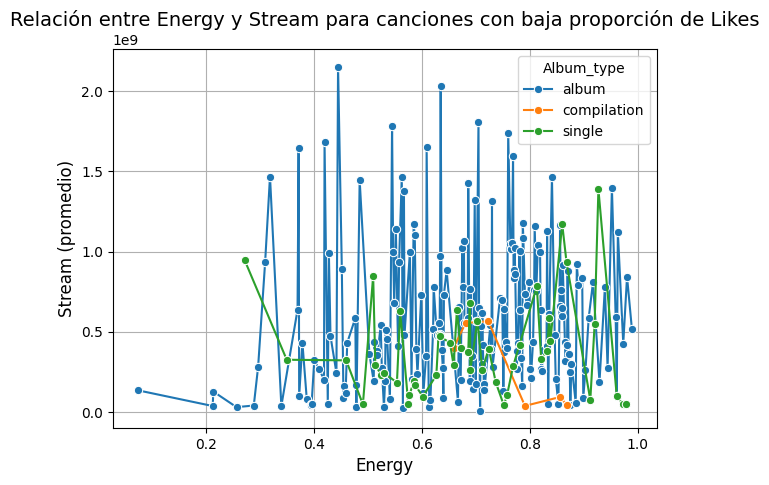

In [29]:
# Promedio de "Stream" por "Energy" y "Album_type" en el subconjunto `low_likes`
trend_data = low_likes.groupby(['Album_type', 'Energy']).agg({'Stream': 'mean'}).reset_index()


# Personalizar el gráfico
plt.title('Relación entre Energy y Stream para canciones con baja proporción de Likes', fontsize=14)
plt.xlabel('Energy', fontsize=12)
plt.ylabel('Stream (promedio)', fontsize=12)
plt.legend(title='Album Type')
plt.grid(True)
plt.tight_layout()
sns.lineplot(data=trend_data, x='Energy', y='Stream', hue='Album_type', marker='o')

## Ejercicio 6: Rango de valores de danceability

**Utiliza el dataFrame low_likes.**

* Muestra el rango de valores existente promedio de danceability para los diferentes tipos de canciones en spotify (columna Album_type) en un mapa de calor.
* Asegúrate de incluir una barra de colores, etiquetas de ejes, y un título descriptivo.

<Axes: title={'center': 'Mapa de calor de promedio de bailabilidad segun el tipo de canción'}, ylabel='Album_type'>

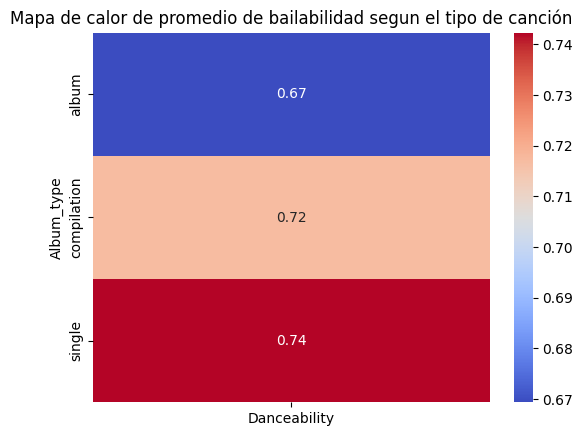

In [30]:
heatmap_data = low_likes.groupby('Album_type', as_index=False)['Danceability'].mean().set_index('Album_type')

# Personalizar el mapa de calor
plt.title('Mapa de calor de promedio de bailabilidad segun el tipo de canción')
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f')

## Ejercicio 7: Análisis de Artistas

**Utiliza el dataFrame low_likes.**

* Identifica los tres artistas con el mayor total de "Stream" en este subconjunto.
* Presenta un dataFrame con el nombre del artista y el total correspondiente, ordenados de mayor a menor.
* Genera un gráfico de barras que compare estos totales entre los artistas identificados, en el eje X debe ir la variable stream y en el eje Y la variable Artist, para ello utiliza el método barplot() de la librería seaborn.

       Artist      Stream
0   Sam Smith  4775584963
1  Katy Perry  4655495877
2     Rihanna  4641586971


/var/folders/_4/dfs0n0dj0g90v58df_9xh4000000gn/T/ipykernel_55876/1611777431.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_artists, x='Artist', y='Stream', palette='viridis')


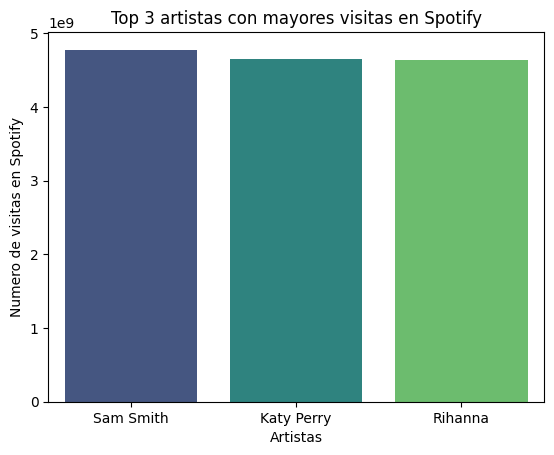

In [31]:
# Identificar los tres artistas con el mayor total de "Stream"
top_artists = low_likes.groupby('Artist')['Stream'].sum().sort_values(ascending=False).reset_index().head(3)

# Personalizar el gráfico
plt.title('Top 3 artistas con mayores visitas en Spotify')
plt.xlabel('Artistas')
plt.ylabel('Numero de visitas en Spotify')

# Crear un gráfico de barras para comparar los totales
sns.barplot(data=top_artists, x='Artist', y='Stream', palette='viridis')

# Mostrar los datos del análisis
print(top_artists)